In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

In [2]:
# Générer des données synthétiques
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
print(f"Shape des données: {X.shape}")
print(f"Nombre d'observations: {X.shape[0]}")
print(f"Nombre de features: {X.shape[1]}")

Shape des données: (300, 2)
Nombre d'observations: 300
Nombre de features: 2


In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

In [4]:
print(f"Inertie (variance intra-cluster): {kmeans.inertia_:.2f}")
print(f"Nombre d'itérations: {kmeans.n_iter_}")
print(f"Centres (centroïdes):")
print(kmeans.cluster_centers_)

Inertie (variance intra-cluster): 203.89
Nombre d'itérations: 2
Centres (centroïdes):
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]


46.618448909756
48.7965553109609
56.21016149449213
52.26558112537435


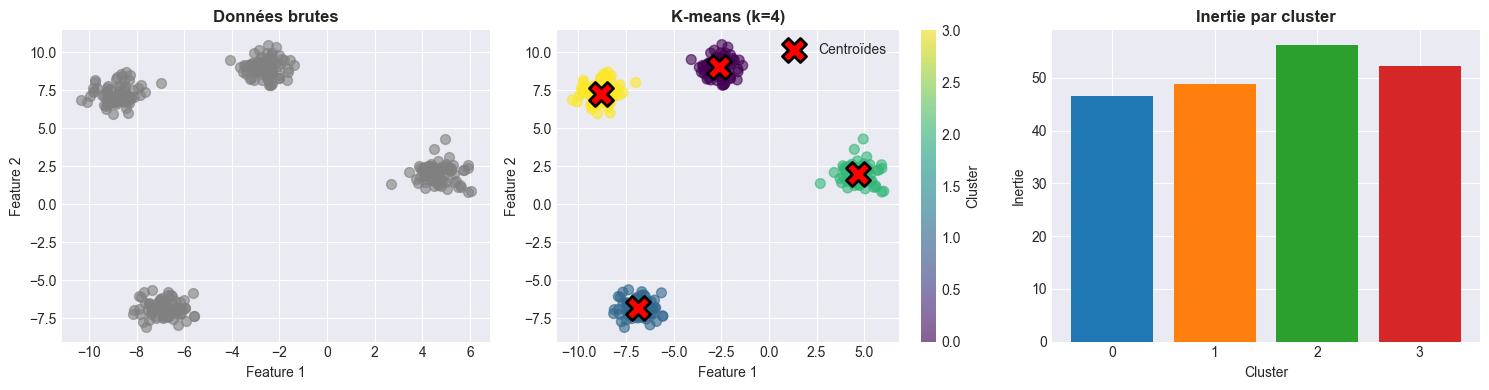

Inertie totale: 203.89


In [5]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Données brutes
axes[0].scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6, s=50)
axes[0].set_title('Données brutes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Clusters prédits
scatter = axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6, s=50)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroïdes')
axes[1].set_title(f'K-means (k=4)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
plt.colorbar(scatter, ax=axes[1], label='Cluster')

# Inertie par cluster
inertia_by_cluster = []
for i in range(4):
    cluster_points = X[y_pred == i]
    center = kmeans.cluster_centers_[i]
    inertia = np.sum((cluster_points - center) ** 2)
    print(inertia)
    inertia_by_cluster.append(inertia)

axes[2].bar(range(4), inertia_by_cluster, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[2].set_title('Inertie par cluster', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Inertie')
axes[2].set_xticks(range(4))

plt.tight_layout()
plt.show()

print(f"Inertie totale: {sum(inertia_by_cluster):.2f}")

In [6]:
kmeans_good = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=42)
y_pred_good = kmeans_good.fit_predict(X)

print(f"K-means avec k-means++")
print(f"Inertie: {kmeans_good.inertia_:.2f}")
print(f"Nombre d'initialisations: 20")
print(f"\n Distribution des clusters:")
unique, counts = np.unique(y_pred_good, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} points ({count/len(y_pred_good)*100:.1f}%)")

K-means avec k-means++
Inertie: 203.89
Nombre d'initialisations: 20

 Distribution des clusters:
  Cluster 0: 75 points (25.0%)
  Cluster 1: 75 points (25.0%)
  Cluster 2: 75 points (25.0%)
  Cluster 3: 75 points (25.0%)


In [7]:
# Calculer l'inertie pour différentes valeurs de k
inertias_list = []
silhouette_scores = []
k_values = range(1, 11)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    y_pred_temp = kmeans_temp.fit_predict(X)
    inertias_list.append(kmeans_temp.inertia_)
    
    # Silhouette ne peut pas être calculé pour k=1
    if k > 1:
        score = silhouette_score(X, y_pred_temp)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

print("k\tInertie\t\tSilhouette")
for k, inertia, sil in zip(k_values, inertias_list, silhouette_scores):
    print(f"{k}\t{inertia:.2f}\t\t{sil:.4f}")

k	Inertie		Silhouette
1	19652.40		0.0000
2	9051.82		0.6155
3	1773.74		0.7993
4	203.89		0.8756
5	184.41		0.7552
6	165.72		0.6102
7	148.07		0.4540
8	129.73		0.3411
9	117.92		0.3379
10	104.54		0.3592
